# fMRI Anomaly Detection — T4 x2 Modeling Notebook

This notebook implements a full **normative modeling pipeline** for resting-state fMRI anomaly detection.

## Pipeline Overview
1. Load preprocessed brain clips from `data-preprocessing-kaggle.ipynb`
2. Generate synthetic anomalies for evaluation
3. Train models from simple → complex (2D CNN → 3D CNN → UNet3D → Residual3D)
4. Benchmark all models on AUC, TPR, FPR
5. Explainable AI (XAI): reconstruction heatmaps, gradient saliency, occlusion sensitivity
6. UMAP latent space visualization
7. Demographics breakdown

**Hardware:** Kaggle T4 x2 (2 × 16 GB = 32 GB VRAM) — DataParallel + mixed precision


## Cell 1 — GPU Verification

Confirm both T4 GPUs are visible before training. If only 1 GPU shows up, check Kaggle
accelerator is set to **GPU T4 x2** in the notebook settings.


In [12]:
import torch

print(f"PyTorch : {torch.__version__}")
print(f"GPUs    : {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    cap  = torch.cuda.get_device_capability(i)
    name = torch.cuda.get_device_name(i)
    mem  = torch.cuda.get_device_properties(i).total_memory / 1024**3
    print(f"  GPU {i}: {name}  (sm_{cap[0]}{cap[1]},  {mem:.0f} GB)")


PyTorch : 2.10.0+cu128
GPUs    : 2
  GPU 0: Tesla T4  (sm_75,  15 GB)
  GPU 1: Tesla T4  (sm_75,  15 GB)


## Cell 2 — Imports

Standard scientific Python stack plus PyTorch and sklearn metrics.


In [13]:
import os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")
print("Imports OK")


Imports OK


## Cell 3 — Device Setup

`resolve_device()` does a functional smoke-test (actually runs a Conv3d on the GPU)
rather than trusting `get_arch_list()`, which Kaggle's PyTorch build sometimes omits
for valid architectures.


In [14]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


def resolve_device():
    if not torch.cuda.is_available():
        print("CUDA not available — using CPU.")
        return "cpu"
    try:
        test = torch.zeros((1, 1, 4, 4, 4), device="cuda")
        conv = nn.Conv3d(1, 1, kernel_size=3, padding=1).to("cuda")
        _ = conv(test)
        cap  = torch.cuda.get_device_capability()
        name = torch.cuda.get_device_name(0)
        print(f"CUDA OK — {name} (sm_{cap[0]}{cap[1]})")
        return "cuda"
    except Exception as exc:
        print(f"CUDA not usable, falling back to CPU: {exc}")
        return "cpu"


DEVICE   = resolve_device()
NUM_GPUS = torch.cuda.device_count() if DEVICE == "cuda" else 0
print(f"Device: {DEVICE}  |  GPUs: {NUM_GPUS}")

if DEVICE == "cuda":
    torch.backends.cudnn.benchmark        = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.set_float32_matmul_precision("high")


CUDA OK — Tesla T4 (sm_75)
Device: cuda  |  GPUs: 2


## Cell 4 — Hyperparameters & Model Configurations

The input shape is fixed by the preprocessing notebook:
`(N, 1, 16, 64, 64)` — N subjects × 1 channel × 16 time frames × 64×64 pixels.

### T4 x2 Settings
| Setting | Value | Reason |
|---|---|---|
| `BATCH_SIZE` | 8 | DataParallel splits across 2 GPUs (4 per GPU) |
| `ACCUM_STEPS` | 2 | Effective batch = 16 |
| Mixed precision | On | ~2× throughput on T4 (sm_75) |
| `EPOCHS` | 100 | With early stopping (patience=15) |

### Model Progression
We benchmark 4 models from simplest to most complex:
- **simple_2d**: 2D CNN AE — treats each frame independently (~0.1M params)
- **simple_3d**: Basic 3D CNN AE — learns spatiotemporal patterns (~0.5M params)
- **unet3d**: 3D UNet with skip connections — better detail reconstruction (~2M params)
- **res3d**: Residual 3D AE — strongest representational capacity (~5-10M params)


In [15]:
# ── Input shape (fixed by preprocessing notebook) ─────────────────────────────
IN_CHANNELS = 1    # single channel
N_FRAMES    = 16   # time frames per clip
HW          = 64   # spatial size (H=W=64)

# ── DataLoader ────────────────────────────────────────────────────────────────
BATCH_SIZE  = 4 * max(1, NUM_GPUS)          # 8 on T4x2
ACCUM_STEPS = 2
NUM_WORKERS = min(4, 2 * max(1, NUM_GPUS))

# ── Optimiser ─────────────────────────────────────────────────────────────────
LR           = 1e-3 * max(1, NUM_GPUS)
WEIGHT_DECAY = 1e-4
GRAD_CLIP    = 1.0

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS   = 100
PATIENCE = 15

# ── Output ────────────────────────────────────────────────────────────────────
OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Model configs (name, architecture type, hyperparams) ──────────────────────
MODEL_CONFIGS = [
    {"name": "simple_2d",  "arch": "simple_2d",  "base_channels": 16},
    {"name": "simple_3d",  "arch": "simple_3d",  "base_channels": 16},
    {"name": "unet3d_16",  "arch": "unet3d",     "base_channels": 16},
    {"name": "res3d_24",   "arch": "res3d",      "base_channels": 24, "dropout": 0.1},
]

# CPU fallback for local debugging
if DEVICE == "cpu":
    BATCH_SIZE   = 1
    ACCUM_STEPS  = 1
    NUM_WORKERS  = 0
    EPOCHS       = 20
    PATIENCE     = 5
    LR           = 1e-3
    GRAD_CLIP    = 0.5
    MODEL_CONFIGS = [
        {"name": "simple_2d", "arch": "simple_2d", "base_channels": 8},
        {"name": "simple_3d", "arch": "simple_3d", "base_channels": 8},
    ]

print(f"BATCH={BATCH_SIZE}  ACCUM={ACCUM_STEPS}  eff_batch={BATCH_SIZE*ACCUM_STEPS}  LR={LR:.2e}")
print(f"Models to train: {[c['name'] for c in MODEL_CONFIGS]}")


BATCH=8  ACCUM=2  eff_batch=16  LR=2.00e-03
Models to train: ['simple_2d', 'simple_3d', 'unet3d_16', 'res3d_24']


## Cell 5 — Load Preprocessed Clips

The preprocessing notebook (`data-preprocessing-kaggle.ipynb`) produced:
- `preprocessed_clips.npy` — shape (N, 1, 16, 64, 64), already smoothed + bandpass filtered + standardized
- `clip_metadata.csv` — subject ID, sex, age per clip

**Why use preprocessed clips instead of raw NIfTI?**
The preprocessing pipeline applied 6mm spatial smoothing, 0.01–0.1 Hz bandpass filtering,
detrending, and z-score standardization. Feeding raw BOLD signal directly to the autoencoder
means it would learn to reconstruct artifacts and scanner noise instead of neural patterns.

This cell searches for the preprocessed output in `/kaggle/working` (if using the output
of a prior kernel run) or `/kaggle/input` (if the preprocessing notebook's dataset was
added to this kernel).


In [16]:
# =============================================================
# Cell 5: Load Preprocessed Clips (FIXED for your dataset)
# =============================================================
from pathlib import Path
import numpy as np
import pandas as pd

# Search for preprocessed_clips.npy
clips_path = None

# Try specific paths first (faster)
possible_paths = [
    # Your uploaded dataset "Preprocessing output"
    Path("/kaggle/input/preprocessing-output/preprocessed_clips.npy"),
    Path("/kaggle/input/preprocessing-output/preprocessed/preprocessed_clips.npy"),
    Path("/kaggle/input/preprocessingoutput/preprocessed_clips.npy"),
    Path("/kaggle/input/preprocessingoutput/preprocessed/preprocessed_clips.npy"),
    # Case insensitive variations
    Path("/kaggle/input/Preprocessing output/preprocessed_clips.npy"),
    Path("/kaggle/input/Preprocessing_output/preprocessed_clips.npy"),
    Path("/kaggle/input/preprocessing_output/preprocessed_clips.npy"),
    # Previous working directory (if same session)
    Path("/kaggle/working/preprocessed/preprocessed_clips.npy"),
]

for path in possible_paths:
    if path.exists():
        clips_path = path
        break

# If not found, search recursively in /kaggle/input
if clips_path is None:
    print("Searching recursively in /kaggle/input...")
    for p in Path("/kaggle/input").rglob("preprocessed_clips.npy"):
        clips_path = p
        break

# If still not found, show what IS in the input directory
if clips_path is None:
    print("\n❌ preprocessed_clips.npy not found!")
    print("\n📁 Contents of /kaggle/input:")
    for item in Path("/kaggle/input").iterdir():
        if item.is_dir():
            print(f"  📁 {item.name}")
            # Show what's inside each subdirectory
            for subitem in item.iterdir():
                if subitem.is_file():
                    print(f"      📄 {subitem.name}")
                elif subitem.is_dir():
                    print(f"      📁 {subitem.name}/")
                    # One level deeper
                    for subsub in subitem.iterdir():
                        if subsub.is_file():
                            print(f"          📄 {subsub.name}")
    
    raise FileNotFoundError(
        "preprocessed_clips.npy not found.\n\n"
        "Check that:\n"
        "1. You uploaded the dataset named 'Preprocessing output'\n"
        "2. The dataset contains preprocessed_clips.npy\n"
        "3. You added it via 'Add Data' button in this notebook\n\n"
        "Expected path: /kaggle/input/preprocessing-output/preprocessed_clips.npy"
    )

print(f"✅ Found: {clips_path}")
X = np.load(clips_path).astype(np.float32)
print(f"Clips shape: {X.shape}")
print(f"  N={X.shape[0]} subjects, channels={X.shape[1]}, "
      f"T={X.shape[2]} frames, {X.shape[3]}x{X.shape[4]} px")
print(f"  Value range: [{X.min():.3f}, {X.max():.3f}]")

# Load metadata - try multiple possible locations
meta_path = None
possible_meta_paths = [
    clips_path.parent / "clip_metadata.csv",
    clips_path.parent.parent / "clip_metadata.csv",
    Path("/kaggle/input/preprocessing-output/clip_metadata.csv"),
    Path("/kaggle/input/preprocessing-output/preprocessed/clip_metadata.csv"),
]

for p in possible_meta_paths:
    if p.exists():
        meta_path = p
        break

if meta_path and meta_path.exists():
    df_meta = pd.read_csv(meta_path)
    print(f"\n✅ Metadata: {df_meta.shape[0]} rows, columns: {list(df_meta.columns)}")
    print(df_meta.head())
else:
    print("\n⚠️ No metadata CSV found — using placeholder demographics.")
    df_meta = pd.DataFrame({
        "subject": [f"sub_{i:03d}" for i in range(len(X))],
        "sex": ["Unknown"] * len(X),
        "age": [np.nan] * len(X),
    })

# Verify alignment
assert len(X) == len(df_meta), f"Clips ({len(X)}) vs metadata ({len(df_meta)}) mismatch"
print(f"\n✅ Data loaded successfully: {len(X)} subjects")

Searching recursively in /kaggle/input...
✅ Found: /kaggle/input/datasets/mohamedazizmokhtar/preprocessing-output/preprocessed_clips.npy
Clips shape: (103, 1, 16, 64, 64)
  N=103 subjects, channels=1, T=16 frames, 64x64 px
  Value range: [0.000, 1.000]

✅ Metadata: 103 rows, columns: ['subject', 'filename', 'sex', 'age']
        subject          filename     sex  age
0  f20_414egowe  f20_414egowe.nii  Female   20
1  f20_636af7ma  f20_636af7ma.nii  Female   20
2  f20_7klsus1s  f20_7klsus1s.nii  Female   20
3  f21_16fafrs1  f21_16fafrs1.nii  Female   21
4  f21_5cestsd1  f21_5cestsd1.nii  Female   21

✅ Data loaded successfully: 103 subjects


## Cell 6 — Visualize Sample Clips

Each clip is a sequence of 16 axial brain slices (64×64 pixels) spanning the middle
of the resting-state scan. Brighter pixels = higher BOLD signal at that location and time.

After preprocessing (smoothing + bandpass + standardize), the clips should show
smooth, slowly-varying spatial patterns — not sharp noisy edges.


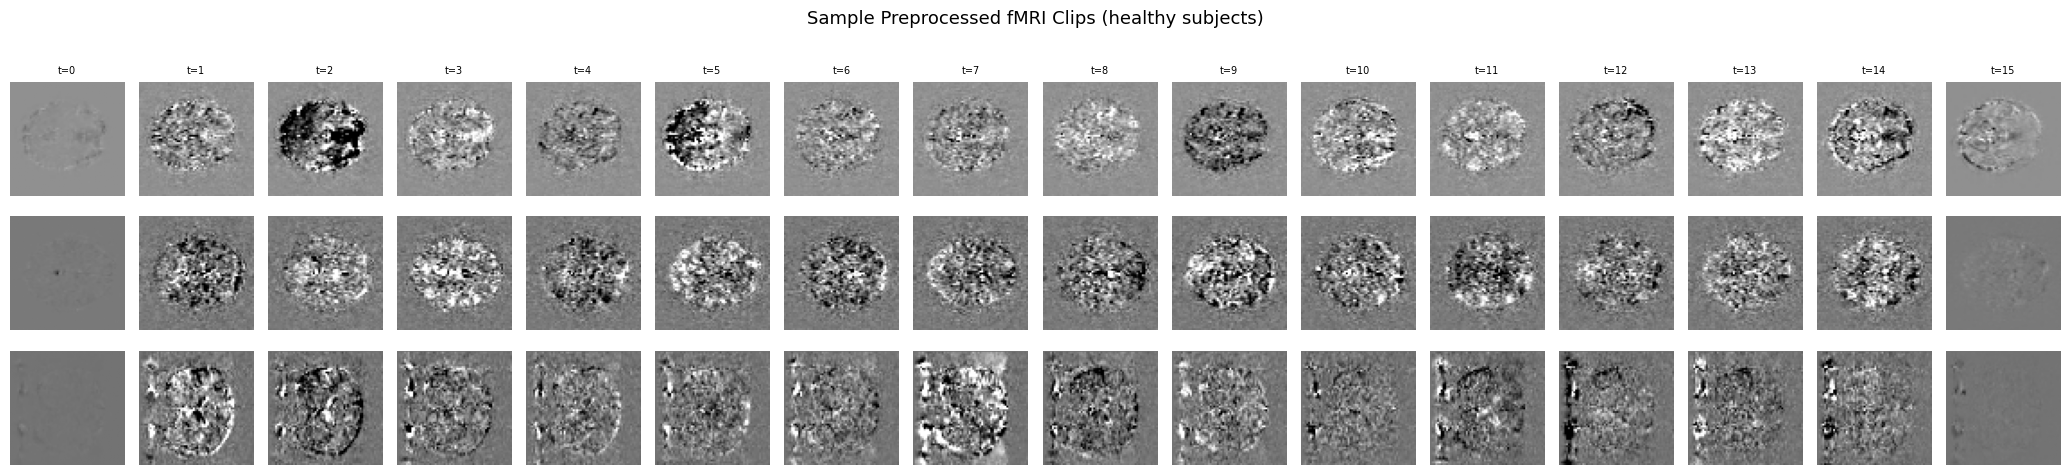

In [17]:
n_show = min(3, len(X))
fig, axes = plt.subplots(n_show, N_FRAMES, figsize=(N_FRAMES * 1.3, n_show * 1.6))
if n_show == 1:
    axes = axes[np.newaxis, :]

for row in range(n_show):
    subj_name = df_meta.iloc[row]["subject"] if "subject" in df_meta.columns else f"sub_{row}"
    for t in range(N_FRAMES):
        axes[row, t].imshow(X[row, 0, t], cmap="gray", vmin=0, vmax=1)
        axes[row, t].axis("off")
        if row == 0:
            axes[row, t].set_title(f"t={t}", fontsize=7)
    axes[row, 0].set_ylabel(str(subj_name)[:12], fontsize=8, rotation=0,
                            ha="right", va="center")

fig.suptitle("Sample Preprocessed fMRI Clips (healthy subjects)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_clips.png", dpi=120, bbox_inches="tight")
plt.show()


## Cell 7 — Synthetic Anomaly Generation

Since our dataset contains only healthy subjects (no clinical labels), we **synthesize
anomalies** for evaluation. This is the standard approach in normative modeling research
(Zimmerer et al., 2019).

### What makes a good synthetic anomaly?
The corruption must be **detectable** (large enough to affect reconstruction error)
but not so large that it's trivially separable. We use:
1. **Noise patch**: Gaussian noise injected into a random spatiotemporal region (~35% of frames, ~30% of spatial extent)
2. **Temporal spike**: One entire frame boosted by +0.3 signal units (simulates motion artifact)
3. **Global noise**: Small Gaussian noise added everywhere (σ=0.02)

These simulate the kinds of functional disruptions that could indicate hidden cognitive
imbalance or local network dysfunction without gross structural changes.


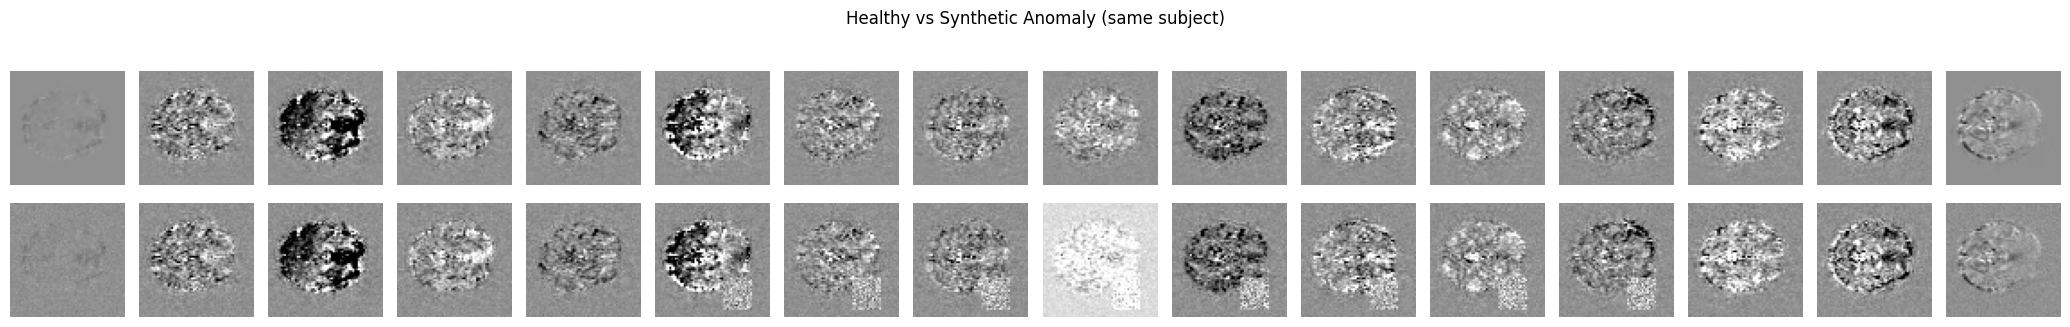

Anomaly injection function ready.


In [18]:
def random_span(rng, size, min_sz, max_sz):
    span  = int(np.clip(rng.integers(min_sz, max_sz + 1), 1, size))
    start = int(rng.integers(0, max(1, size - span + 1)))
    return start, min(size, start + span)


def inject_anomaly(clip_1thw, rng):
    """Corrupt clip (1, T, H, W) with spatiotemporal noise. Returns copy."""
    out = clip_1thw.copy()
    _, T, H, W = out.shape

    # 1. Noise patch in a random spatiotemporal region
    t0, t1 = random_span(rng, T, max(2, T // 4), max(4, T // 2))
    y0, y1 = random_span(rng, H, max(4, H // 6), max(8, H // 3))
    x0, x1 = random_span(rng, W, max(4, W // 6), max(8, W // 3))
    noise = rng.normal(0.7, 0.15, (t1-t0, y1-y0, x1-x0)).astype(np.float32)
    out[0, t0:t1, y0:y1, x0:x1] = np.clip(noise, 0.0, 1.0)

    # 2. Temporal spike on one random frame
    t_spike = int(rng.integers(0, T))
    out[0, t_spike] = np.clip(out[0, t_spike] + 0.3, 0.0, 1.0)

    # 3. Small global noise
    out = np.clip(out + rng.normal(0.0, 0.02, out.shape).astype(np.float32), 0.0, 1.0)
    return out


# Visualize healthy vs anomalous
rng_demo = np.random.default_rng(7)
demo_clip = X[0].copy()
demo_anom = inject_anomaly(demo_clip, rng_demo)

fig, axes = plt.subplots(2, N_FRAMES, figsize=(N_FRAMES * 1.3, 3.5))
for t in range(N_FRAMES):
    axes[0, t].imshow(demo_clip[0, t], cmap="gray", vmin=0, vmax=1)
    axes[0, t].axis("off")
    axes[1, t].imshow(demo_anom[0, t], cmap="gray", vmin=0, vmax=1)
    axes[1, t].axis("off")
    if t == 0:
        axes[0, t].set_ylabel("Healthy", fontsize=9, rotation=0, ha="right", va="center")
        axes[1, t].set_ylabel("Anomalous", fontsize=9, rotation=0, ha="right", va="center")

fig.suptitle("Healthy vs Synthetic Anomaly (same subject)", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "healthy_vs_anomaly.png", dpi=120, bbox_inches="tight")
plt.show()

print("Anomaly injection function ready.")


## Cell 8 — Data Splits & DataLoaders

### Why three splits?
| Set | Fraction | Purpose |
|---|---|---|
| **Train** | 70% | The autoencoder learns what healthy brains look like |
| **Calibration** | 15% | Sets the anomaly threshold (95th percentile of healthy errors) |
| **Test** | 15% | Measures FPR on unseen healthy subjects |

The calibration set acts as a held-out threshold tuner — using the training set for
this would overfit the threshold to the training distribution.

The **anomaly set** = same subjects as test, but with synthetic corruption applied.
It measures the True Positive Rate (TPR) — what fraction of anomalies we catch.


In [19]:
# =============================================================
# Cell 8: Data Splits & DataLoaders (FIXED)
# =============================================================

class PreprocessedClipDataset(Dataset):
    def __init__(self, clips, transform=None):
        """clips: np.ndarray (N, 1, T, H, W)"""
        self.clips = clips
        self.transform = transform

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, idx):
        clip = self.clips[idx].copy()
        if self.transform is not None:
            clip = self.transform(clip)
        # Return as tuple with one element (for consistency)
        return (torch.from_numpy(clip),)  # ← FIX: return a tuple


class AnomalyTransform:
    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)
    def __call__(self, clip):
        return inject_anomaly(clip, self.rng)


# Index-based splits (keep metadata aligned)
idx_all = np.arange(len(X))
idx_train, idx_tmp = train_test_split(idx_all, test_size=0.30, random_state=SEED)
idx_calib, idx_test = train_test_split(idx_tmp, test_size=0.50, random_state=SEED)

X_train = X[idx_train]
X_calib = X[idx_calib]
X_test = X[idx_test]
df_test = df_meta.iloc[idx_test].reset_index(drop=True)

print(f"Subjects — train: {len(X_train)}  calib: {len(X_calib)}  test: {len(X_test)}")

# DataLoaders
pin = (DEVICE == "cuda")
pw = (NUM_WORKERS > 0)
dl_kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
             pin_memory=pin, persistent_workers=pw)

train_loader = DataLoader(PreprocessedClipDataset(X_train), shuffle=True, **dl_kw)
calib_loader = DataLoader(PreprocessedClipDataset(X_calib), shuffle=False, **dl_kw)
test_loader = DataLoader(PreprocessedClipDataset(X_test), shuffle=False, **dl_kw)
anom_loader = DataLoader(
    PreprocessedClipDataset(X_test, transform=AnomalyTransform(seed=SEED+99)),
    shuffle=False, **dl_kw
)

print("DataLoaders ready.")

Subjects — train: 72  calib: 15  test: 16
DataLoaders ready.


## Cell 9 — Model Architectures (Simple → Complex)

All models take input shape `(B, 1, T, H, W)` = (batch, channel=1, 16 frames, 64×64).

### Architecture Progression

| Model | Architecture | Params | Key idea |
|---|---|---|---|
| **Simple2DCNNAE** | 2D Conv AE | ~0.1M | Treats each frame independently — no temporal modeling |
| **Simple3DCNNAE** | 3D Conv AE | ~0.5M | First model to learn spatiotemporal patterns |
| **UNet3DAE** | 3D UNet | ~2M | Skip connections preserve spatial detail |
| **StrongRes3DAE** | Residual 3D AE | ~5-10M | Deepest model with GroupNorm + SiLU |

**Autoencoder principle for anomaly detection:**
Train only on healthy brains → the model learns the normal spatiotemporal fingerprint.
At test time, healthy brains reconstruct well (low error). Anomalous patterns fall
outside the learned distribution → high reconstruction error → flagged as anomalous.


In [20]:
# ── Simple 2D CNN Autoencoder ─────────────────────────────────────────────────
class Simple2DCNNAE(nn.Module):
    """Baseline: each frame processed independently as a 2D image.
    No temporal information — establishes a lower bound on performance."""
    def __init__(self, base_channels=16):
        super().__init__()
        c = base_channels
        self.encoder = nn.Sequential(
            nn.Conv2d(1, c,   3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 32x32
            nn.Conv2d(c, c*2, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 16x16
            nn.Conv2d(c*2, c*4, 3, padding=1), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(c*4, c*2, 2, stride=2), nn.ReLU(),         # 32x32
            nn.ConvTranspose2d(c*2, c,   2, stride=2), nn.ReLU(),         # 64x64
            nn.Conv2d(c, 1, 3, padding=1), nn.Sigmoid(),
        )

    def forward(self, x):
        B, C, T, H, W = x.shape
        x2d = x.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)  # treat frames as batch
        out = self.decoder(self.encoder(x2d))
        return out.reshape(B, T, C, H, W).permute(0, 2, 1, 3, 4)  # → (B,1,T,H,W)


# ── Simple 3D CNN Autoencoder ─────────────────────────────────────────────────
class Simple3DCNNAE(nn.Module):
    """Baseline 3D: learns spatiotemporal patterns with no skip connections."""
    def __init__(self, base_channels=16):
        super().__init__()
        c = base_channels
        self.encoder = nn.Sequential(
            nn.Conv3d(1, c,   3, padding=1), nn.ReLU(), nn.MaxPool3d(2),   # B,c,8,32,32
            nn.Conv3d(c, c*2, 3, padding=1), nn.ReLU(), nn.MaxPool3d(2),   # B,2c,4,16,16
            nn.Conv3d(c*2, c*4, 3, padding=1), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose3d(c*4, c*2, 2, stride=2), nn.ReLU(),          # B,2c,8,32,32
            nn.ConvTranspose3d(c*2, c,   2, stride=2), nn.ReLU(),          # B,c,16,64,64
            nn.Conv3d(c, 1, 3, padding=1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


# ── 3D UNet Autoencoder ───────────────────────────────────────────────────────
class UNet3DAE(nn.Module):
    """3D UNet with skip connections — better spatial detail reconstruction."""
    def __init__(self, base_channels=16):
        super().__init__()
        c = base_channels

        self.enc1     = self._block(1,   c)
        self.down1    = nn.MaxPool3d(2)
        self.enc2     = self._block(c,   c*2)
        self.down2    = nn.MaxPool3d(2)
        self.bottle   = self._block(c*2, c*4)
        self.up2      = nn.ConvTranspose3d(c*4, c*2, kernel_size=2, stride=2)
        self.dec2     = self._block(c*4, c*2)   # c*4 because skip-cat doubles channels
        self.up1      = nn.ConvTranspose3d(c*2, c,   kernel_size=2, stride=2)
        self.dec1     = self._block(c*2, c)
        self.out_conv = nn.Conv3d(c, 1, kernel_size=1)

    @staticmethod
    def _block(in_ch, out_ch):
        g = lambda ch: nn.GroupNorm(min(8, ch), ch)
        return nn.Sequential(
            nn.Conv3d(in_ch,  out_ch, 3, padding=1), g(out_ch), nn.SiLU(),
            nn.Conv3d(out_ch, out_ch, 3, padding=1), g(out_ch), nn.SiLU(),
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.down1(e1))
        b  = self.bottle(self.down2(e2))
        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return torch.sigmoid(self.out_conv(d1))


# ── Strong Residual 3D Autoencoder ────────────────────────────────────────────
def _group_norm(channels, max_groups=8):
    g = min(max_groups, channels)
    while channels % g != 0:
        g -= 1
    return nn.GroupNorm(g, channels)


class ResBlock3D(nn.Module):
    def __init__(self, channels, dropout=0.0):
        super().__init__()
        self.norm1   = _group_norm(channels)
        self.conv1   = nn.Conv3d(channels, channels, 3, padding=1)
        self.norm2   = _group_norm(channels)
        self.conv2   = nn.Conv3d(channels, channels, 3, padding=1)
        self.drop    = nn.Dropout3d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        r = x
        x = self.conv1(F.silu(self.norm1(x)))
        x = self.drop(x)
        x = self.conv2(F.silu(self.norm2(x)))
        return x + r


class StrongRes3DAE(nn.Module):
    """Residual 3D AE with 3 encoder levels, 2-block bottleneck, skip connections."""
    def __init__(self, base_channels=24, dropout=0.0):
        super().__init__()
        c1, c2, c3, c4 = [base_channels * (2**i) for i in range(4)]

        self.stem  = nn.Conv3d(1, c1, 3, padding=1)
        self.enc1  = ResBlock3D(c1, dropout);  self.down1 = nn.Conv3d(c1, c2, 3, stride=2, padding=1)
        self.enc2  = ResBlock3D(c2, dropout);  self.down2 = nn.Conv3d(c2, c3, 3, stride=2, padding=1)
        self.enc3  = ResBlock3D(c3, dropout);  self.down3 = nn.Conv3d(c3, c4, 3, stride=2, padding=1)

        self.bottleneck = nn.Sequential(ResBlock3D(c4, dropout), ResBlock3D(c4, dropout))

        self.up3   = nn.ConvTranspose3d(c4, c3, 2, stride=2); self.dec3 = ResBlock3D(c3, dropout)
        self.up2   = nn.ConvTranspose3d(c3, c2, 2, stride=2); self.dec2 = ResBlock3D(c2, dropout)
        self.up1   = nn.ConvTranspose3d(c2, c1, 2, stride=2); self.dec1 = ResBlock3D(c1, dropout)
        self.out   = nn.Conv3d(c1, 1, 3, padding=1)

    def forward(self, x):
        x  = self.stem(x)
        x1 = self.enc1(x)
        x2 = self.enc2(self.down1(x1))
        x3 = self.enc3(self.down2(x2))
        xb = self.bottleneck(self.down3(x3))
        x  = self.dec3(self.up3(xb) + x3)
        x  = self.dec2(self.up2(x)  + x2)
        x  = self.dec1(self.up1(x)  + x1)
        return torch.sigmoid(self.out(x))

    def encode(self, x):
        """Return bottleneck features (for UMAP/XAI)."""
        x  = self.stem(x)
        x1 = self.enc1(x)
        x2 = self.enc2(self.down1(x1))
        x3 = self.enc3(self.down2(x2))
        return self.bottleneck(self.down3(x3))


# ── Model factory ─────────────────────────────────────────────────────────────
def build_model(cfg, device, num_gpus):
    arch = cfg["arch"]
    bc   = cfg.get("base_channels", 16)
    dp   = cfg.get("dropout", 0.0)

    if arch == "simple_2d":
        model = Simple2DCNNAE(base_channels=bc)
    elif arch == "simple_3d":
        model = Simple3DCNNAE(base_channels=bc)
    elif arch == "unet3d":
        model = UNet3DAE(base_channels=bc)
    elif arch == "res3d":
        model = StrongRes3DAE(base_channels=bc, dropout=dp)
    else:
        raise ValueError(f"Unknown architecture: {arch}")

    model = model.to(device)
    if num_gpus > 1:
        model = nn.DataParallel(model)
        print(f"  DataParallel across {num_gpus} GPUs")

    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  {cfg['name']:15s}  params: {n:,}")
    return model


# Quick param count preview
print("\nModel parameter counts:")
for cfg in MODEL_CONFIGS:
    m = build_model(cfg, "cpu", 0)



Model parameter counts:
  simple_2d        params: 33,729
  simple_3d        params: 90,625
  unet3d_16        params: 339,889
  res3d_24         params: 6,140,545


## Cell 10 — Loss Function & Training Utilities

### Loss: 80% MSE + 20% L1

MSE strongly penalises large reconstruction errors (good for detecting anomalies that
cause big deviations). L1 adds robustness to outlier voxels and sharpens reconstructions.

### Training features
- **Mixed precision (AMP)**: ~2× throughput on T4 by computing in FP16 where safe
- **Gradient accumulation**: Achieves larger effective batch size without more VRAM
- **Gradient clipping**: Prevents exploding gradients in deep residual models
- **Early stopping**: Stops when calibration loss doesn't improve for `PATIENCE` epochs
- **ReduceLROnPlateau**: Halves LR when stuck (factor=0.5, patience=5)


In [21]:
def recon_loss(pred, target):
    return 0.8 * F.mse_loss(pred, target) + 0.2 * F.l1_loss(pred, target)


def train_one_epoch(model, loader, optimizer, scaler, device,
                    accum_steps=1, grad_clip=None):
    model.train()
    running, accum_count = 0.0, 0
    optimizer.zero_grad(set_to_none=True)

    for (xb,) in loader:
        xb = xb.to(device, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            loss = recon_loss(model(xb), xb) / accum_steps

        scaler.scale(loss).backward()
        accum_count += 1

        if accum_count == accum_steps:
            if grad_clip:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            accum_count = 0

        running += loss.item() * accum_steps

    if accum_count > 0:
        if grad_clip:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer); scaler.update()
        optimizer.zero_grad(set_to_none=True)

    return running / max(1, len(loader))


def eval_epoch(model, loader, device):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device, non_blocking=True)
            total += recon_loss(model(xb), xb).item()
    return total / max(1, len(loader))


def fit_model(model, train_loader, val_loader, optimizer, scheduler, device,
              epochs=50, patience=10, accum_steps=1, grad_clip=None):
    scaler        = torch.amp.GradScaler("cuda", enabled=(device == "cuda"))
    best_loss     = float("inf")
    best_state    = None
    patience_left = patience
    history       = []

    for epoch in range(1, epochs + 1):
        tr  = train_one_epoch(model, train_loader, optimizer, scaler,
                              device, accum_steps, grad_clip)
        val = eval_epoch(model, val_loader, device)
        history.append({"epoch": epoch, "train_loss": tr, "val_loss": val})

        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val)
        elif scheduler is not None:
            scheduler.step()

        if val < best_loss - 1e-5:
            best_loss = val
            raw = model.module if isinstance(model, nn.DataParallel) else model
            best_state = {k: v.detach().cpu().clone()
                          for k, v in raw.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1

        if epoch <= 5 or epoch % 10 == 0 or patience_left == 0:
            print(f"  Epoch {epoch:03d} | train {tr:.4f} | val {val:.4f} | "
                  f"best {best_loss:.4f} | lr {optimizer.param_groups[0]['lr']:.2e}")

        if patience_left <= 0:
            print("  Early stopping.")
            break

    return history, best_state


@torch.no_grad()
def reconstruction_errors(model, loader, device):
    """Per-sample mean squared reconstruction error (scalar per subject)."""
    model.eval()
    errors = []
    for (xb,) in loader:
        xb  = xb.to(device, non_blocking=True)
        err = F.mse_loss(model(xb), xb, reduction="none").mean(dim=(1, 2, 3, 4))
        errors.extend(err.cpu().numpy().tolist())
    return np.array(errors)


def unwrap(model):
    """Return raw model, unwrapping DataParallel if needed."""
    return model.module if isinstance(model, nn.DataParallel) else model


## Cell 11 — Train & Benchmark All Models

Each model is trained independently from scratch. After training, we evaluate on:
- **Calibration set** → sets the 95th-percentile anomaly threshold
- **Test set** (healthy) → measures False Positive Rate (FPR)
- **Anomaly set** (synthetically corrupted test) → measures True Positive Rate (TPR)

Results are sorted by AUC descending — the best model is used in all subsequent analysis.


In [22]:
import time

results, states, histories = [], [], []

for cfg in MODEL_CONFIGS:
    print(f"\n{'='*55}")
    print(f"Training: {cfg['name']}  (arch={cfg['arch']})")
    print(f"{'='*55}")
    t0 = time.time()

    model     = build_model(cfg, DEVICE, NUM_GPUS)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, factor=0.5, patience=5, min_lr=1e-6
    )

    history, best_state = fit_model(
        model, train_loader, calib_loader,
        optimizer, scheduler, DEVICE,
        epochs=EPOCHS, patience=PATIENCE,
        accum_steps=ACCUM_STEPS, grad_clip=GRAD_CLIP,
    )

    # Evaluate with a clean (unwrapped) model loaded from best checkpoint
    raw_model = unwrap(model)
    raw_model.load_state_dict(best_state)
    raw_model.eval()

    calib_err = reconstruction_errors(raw_model, calib_loader, DEVICE)
    test_err  = reconstruction_errors(raw_model, test_loader,  DEVICE)
    anom_err  = reconstruction_errors(raw_model, anom_loader,  DEVICE)

    thresh = np.percentile(calib_err, 95)
    y_true = np.r_[np.zeros(len(test_err)), np.ones(len(anom_err))]
    y_sc   = np.r_[test_err, anom_err]
    auc    = roc_auc_score(y_true, y_sc)
    tpr    = float((anom_err > thresh).mean())
    fpr    = float((test_err  > thresh).mean())
    elapsed = time.time() - t0

    print(f"  AUC={auc:.4f}  TPR={tpr:.4f}  FPR={fpr:.4f}  time={elapsed:.0f}s")

    results.append({
        "name": cfg["name"], "arch": cfg["arch"],
        "auc": auc, "tpr_anomaly": tpr, "fpr_healthy": fpr,
        "best_val_loss": min(h["val_loss"] for h in history),
        "train_time_s": round(elapsed),
    })
    states.append(best_state)
    histories.append(history)

benchmark_df = (
    pd.DataFrame(results)
    .sort_values(["auc", "tpr_anomaly", "fpr_healthy"], ascending=[False, False, True])
    .reset_index(drop=True)
)
print("\n" + "="*55)
print("BENCHMARK RESULTS")
print("="*55)
print(benchmark_df[["name", "auc", "tpr_anomaly", "fpr_healthy", "best_val_loss"]].to_string(index=False))



Training: simple_2d  (arch=simple_2d)
  DataParallel across 2 GPUs
  simple_2d        params: 33,729
  Epoch 001 | train 0.0348 | val 0.0335 | best 0.0335 | lr 2.00e-03
  Epoch 002 | train 0.0348 | val 0.0334 | best 0.0334 | lr 2.00e-03
  Epoch 003 | train 0.0347 | val 0.0338 | best 0.0334 | lr 2.00e-03
  Epoch 004 | train 0.0346 | val 0.0329 | best 0.0329 | lr 2.00e-03
  Epoch 005 | train 0.0346 | val 0.0334 | best 0.0329 | lr 2.00e-03
  Epoch 010 | train 0.0310 | val 0.0298 | best 0.0274 | lr 2.00e-03
  Epoch 020 | train 0.0272 | val 0.0242 | best 0.0242 | lr 2.00e-03
  Epoch 030 | train 0.0263 | val 0.0240 | best 0.0233 | lr 1.00e-03
  Epoch 040 | train 0.0248 | val 0.0221 | best 0.0220 | lr 1.00e-03
  Epoch 050 | train 0.0241 | val 0.0214 | best 0.0214 | lr 1.00e-03
  Epoch 060 | train 0.0236 | val 0.0209 | best 0.0209 | lr 1.00e-03
  Epoch 070 | train 0.0234 | val 0.0206 | best 0.0206 | lr 1.00e-03
  Epoch 080 | train 0.0232 | val 0.0204 | best 0.0204 | lr 1.00e-03
  Epoch 090 | 

## Cell 12 — Best Model: Training Curves & Error Distributions

The best model (highest AUC) is selected from the benchmark for all subsequent analysis.

**Training curve**: Validation loss should follow training loss closely (no divergence = no overfitting).
An autoencoder that overfits would memorize training subjects and fail to generalize its reconstruction
to the held-out calibration set.

**Error histogram**: Healthy and anomalous distributions should be separable. The red threshold line
(95th percentile of calibration errors) is the anomaly decision boundary.


Best model: unet3d_16
  unet3d_16        params: 339,889


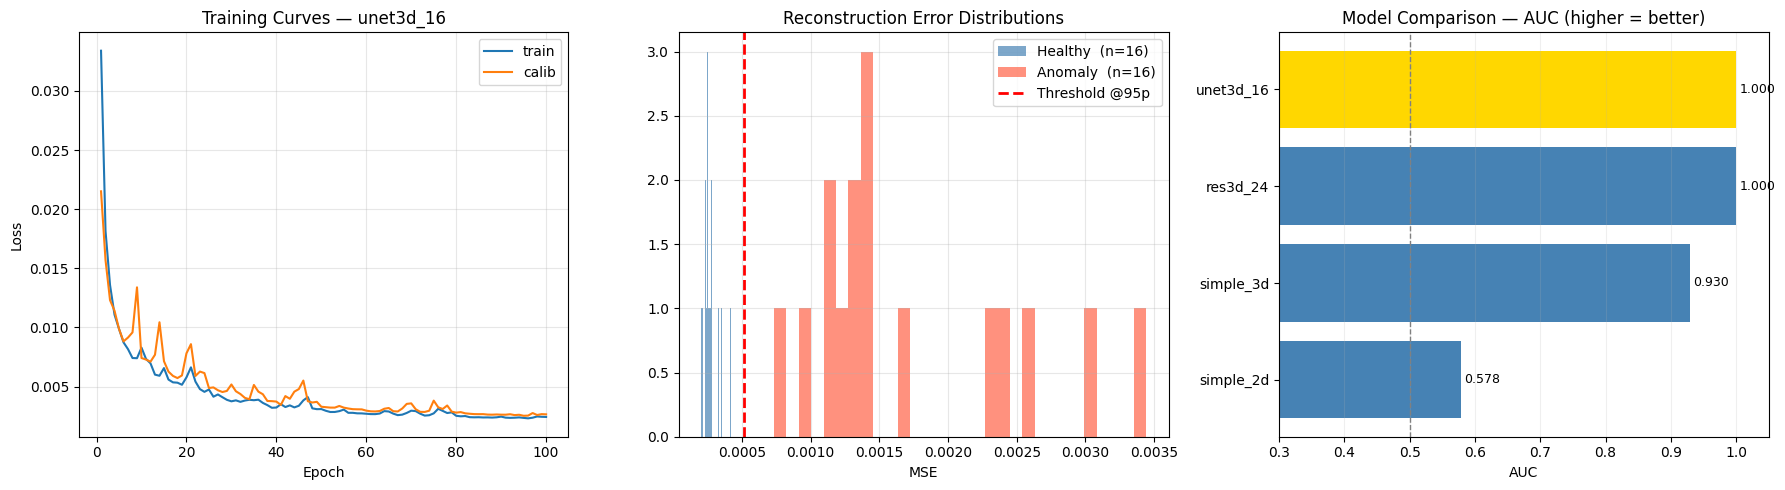

AUC: 1.0000  TPR@95p: 1.0000  FPR@95p: 0.0000  Threshold: 0.00052


In [23]:
best_idx   = int(benchmark_df.index[0])
best_cfg   = MODEL_CONFIGS[benchmark_df.iloc[0].name == pd.Series([c["name"] for c in MODEL_CONFIGS])].squeeze() if False else MODEL_CONFIGS[results.index(next(r for r in results if r["name"] == benchmark_df.iloc[0]["name"]))]
best_state = states[results.index(next(r for r in results if r["name"] == benchmark_df.iloc[0]["name"]))]
best_hist  = histories[results.index(next(r for r in results if r["name"] == benchmark_df.iloc[0]["name"]))]

print(f"Best model: {best_cfg['name']}")

# Rebuild best model from checkpoint
best_model = unwrap(build_model(best_cfg, DEVICE, 0))
best_model.load_state_dict(best_state)
best_model.eval()

calib_err = reconstruction_errors(best_model, calib_loader, DEVICE)
test_err  = reconstruction_errors(best_model, test_loader,  DEVICE)
anom_err  = reconstruction_errors(best_model, anom_loader,  DEVICE)
thresh    = np.percentile(calib_err, 95)

y_true = np.r_[np.zeros(len(test_err)), np.ones(len(anom_err))]
y_sc   = np.r_[test_err, anom_err]
auc    = roc_auc_score(y_true, y_sc)
tpr    = float((anom_err > thresh).mean())
fpr    = float((test_err  > thresh).mean())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training curves
ep = [h["epoch"] for h in best_hist]
axes[0].plot(ep, [h["train_loss"] for h in best_hist], label="train")
axes[0].plot(ep, [h["val_loss"]   for h in best_hist], label="calib")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title(f"Training Curves — {best_cfg['name']}"); axes[0].legend()
axes[0].grid(alpha=0.3)

# Error histogram
axes[1].hist(test_err, bins=30, alpha=0.7, label=f"Healthy  (n={len(test_err)})", color="steelblue")
axes[1].hist(anom_err, bins=30, alpha=0.7, label=f"Anomaly  (n={len(anom_err)})", color="tomato")
axes[1].axvline(thresh, color="red", ls="--", lw=2, label=f"Threshold @95p")
axes[1].set_xlabel("MSE"); axes[1].set_title("Reconstruction Error Distributions")
axes[1].legend(); axes[1].grid(alpha=0.3)

# Model comparison AUC bar chart
axes[2].barh(benchmark_df["name"][::-1], benchmark_df["auc"][::-1],
             color=["gold" if i == 0 else "steelblue" for i in range(len(benchmark_df))[::-1]])
axes[2].set_xlabel("AUC")
axes[2].set_title("Model Comparison — AUC (higher = better)")
axes[2].axvline(0.5, color="gray", ls="--", lw=1, label="Random (0.5)")
for i, (_, row) in enumerate(benchmark_df[::-1].iterrows()):
    axes[2].text(row["auc"] + 0.005, i, f'{row["auc"]:.3f}', va="center", fontsize=9)
axes[2].set_xlim(0.3, 1.05)
axes[2].grid(alpha=0.2, axis="x")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_results.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"AUC: {auc:.4f}  TPR@95p: {tpr:.4f}  FPR@95p: {fpr:.4f}  Threshold: {thresh:.5f}")


## Cell 13 — ROC & Precision-Recall Curves

**ROC curve** (Receiver Operating Characteristic): plots TPR vs. FPR at every possible threshold.
AUC = area under the ROC curve; random detector = 0.5, perfect = 1.0.

**Precision-Recall curve**: more informative than ROC when anomalies are rare (imbalanced).
Average Precision (AP) = area under the PR curve; random = base rate (50% here), perfect = 1.0.

The red dot marks our operating point (95th percentile threshold).


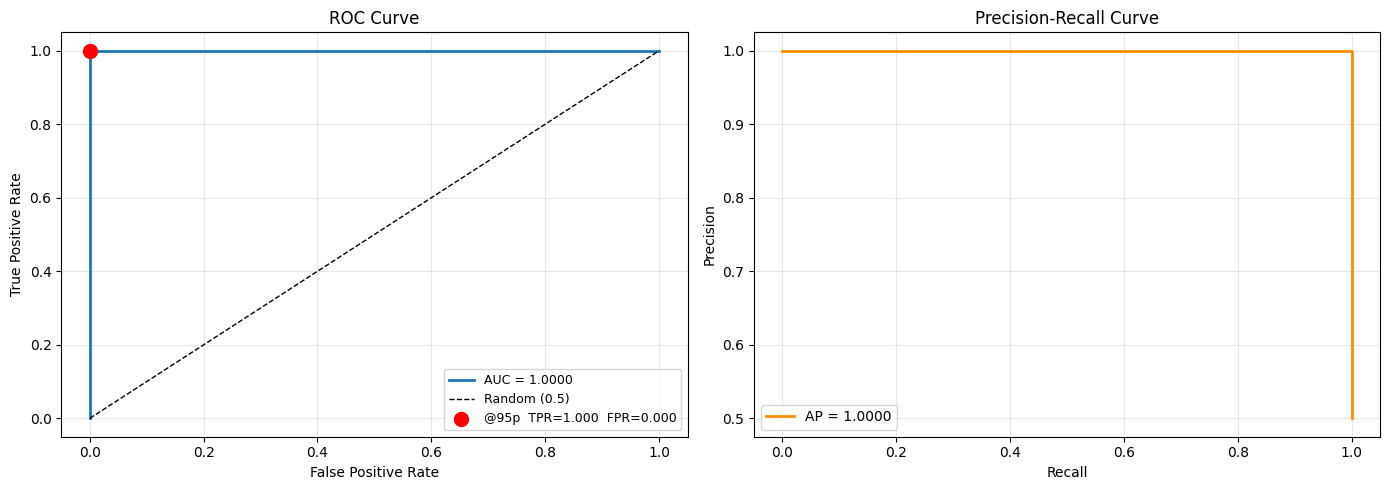

AUC: 1.0000  AP: 1.0000


In [24]:
fpr_c, tpr_c, roc_t = roc_curve(y_true, y_sc)
prec_c, rec_c, _    = precision_recall_curve(y_true, y_sc)
ap = average_precision_score(y_true, y_sc)

# Find closest threshold to our operating point
op_idx = int(np.argmin(np.abs(roc_t - thresh)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
axes[0].plot(fpr_c, tpr_c, lw=2, label=f"AUC = {auc:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Random (0.5)")
axes[0].scatter(fpr_c[op_idx], tpr_c[op_idx], color="red", zorder=5, s=100,
                label=f"@95p  TPR={tpr_c[op_idx]:.3f}  FPR={fpr_c[op_idx]:.3f}")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve"); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# PR
axes[1].plot(rec_c, prec_c, lw=2, color="darkorange", label=f"AP = {ap:.4f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_pr_curves.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"AUC: {auc:.4f}  AP: {ap:.4f}")


## Cell 14 — Per-Subject Anomaly Scores

Each dot is one subject. Healthy subjects (blue) should cluster below the threshold
(red dashed line). Anomalous subjects (red dots) should cluster above.

**Cohen's d** measures the separation between the two distributions in units of pooled
standard deviation. d > 2 = excellent separation, d > 1 = good, d > 0.5 = moderate.


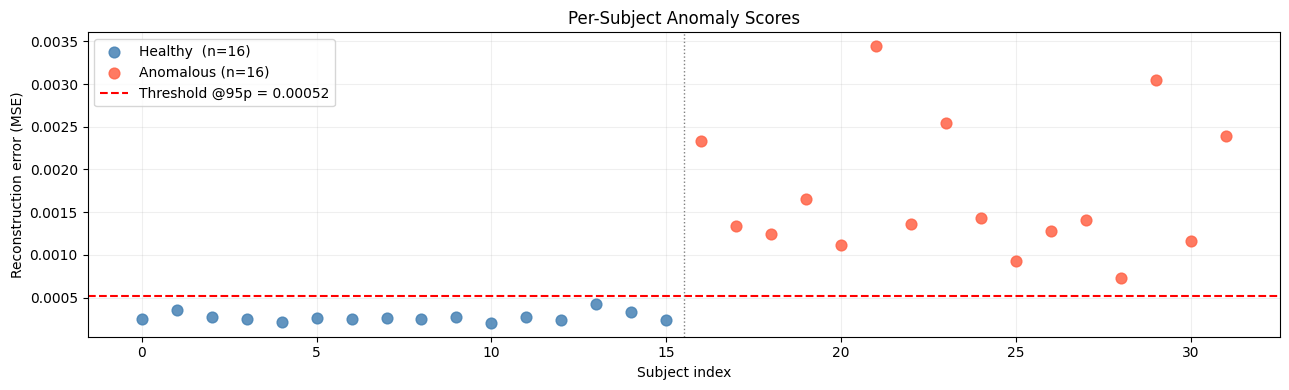

Healthy  — mean: 0.00027  std: 0.00005
Anomaly  — mean: 0.00171  std: 0.00077
Cohen's d: 2.657  (excellent separation)


In [25]:
fig, ax = plt.subplots(figsize=(13, 4))
x_h = np.arange(len(test_err))
x_a = np.arange(len(test_err), len(test_err) + len(anom_err))

ax.scatter(x_h, test_err,  color="steelblue", s=60, alpha=0.85, zorder=3,
           label=f"Healthy  (n={len(test_err)})")
ax.scatter(x_a, anom_err, color="tomato",    s=60, alpha=0.85, zorder=3,
           label=f"Anomalous (n={len(anom_err)})")
ax.axhline(thresh, color="red", ls="--", lw=1.5, label=f"Threshold @95p = {thresh:.5f}")
ax.axvline(len(test_err) - 0.5, color="gray", ls=":", lw=1)
ax.set_xlabel("Subject index"); ax.set_ylabel("Reconstruction error (MSE)")
ax.set_title("Per-Subject Anomaly Scores"); ax.legend(); ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "per_subject_scatter.png", dpi=130, bbox_inches="tight")
plt.show()

cohen_d = (anom_err.mean() - test_err.mean()) / np.sqrt(
    (anom_err.std()**2 + test_err.std()**2) / 2
)
label_d = "excellent" if cohen_d > 2 else "good" if cohen_d > 1 else "moderate"
print(f"Healthy  — mean: {test_err.mean():.5f}  std: {test_err.std():.5f}")
print(f"Anomaly  — mean: {anom_err.mean():.5f}  std: {anom_err.std():.5f}")
print(f"Cohen's d: {cohen_d:.3f}  ({label_d} separation)")


## Cell 15 — XAI: Reconstruction Error Heatmap

The simplest XAI method for autoencoders: for each voxel, compute the squared difference
between input and reconstruction. High error = the model was surprised by that region,
which means that region contains unusual patterns relative to the healthy training data.

**What to look for:**
- Healthy: error should be uniformly low, concentrated in high-frequency edges
- Anomalous: error should spike in the corrupted region (bright spots on the heatmap)

This visualization answers: **WHERE in the brain is the anomaly?**


── Healthy subject ──────────────────────────────────────────────────


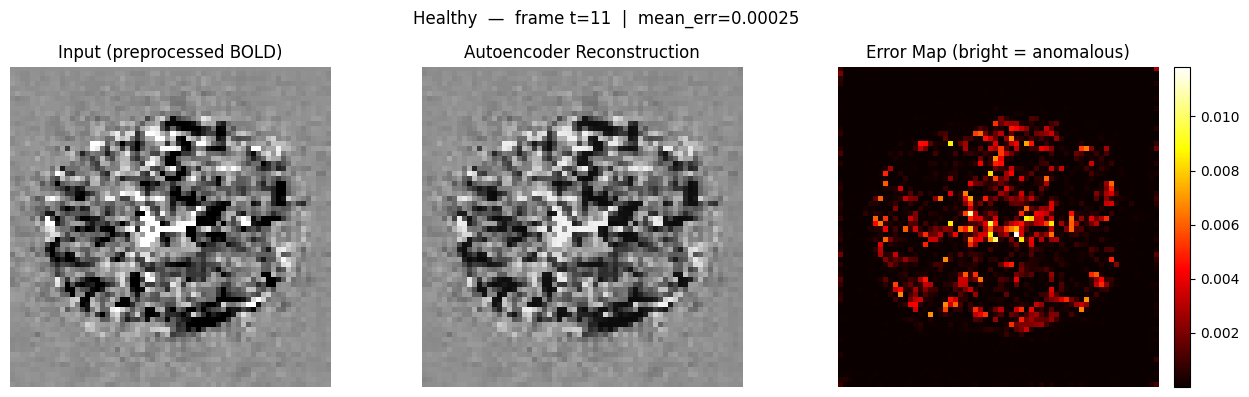

── Anomalous subject (synthetic corruption) ─────────────────────────


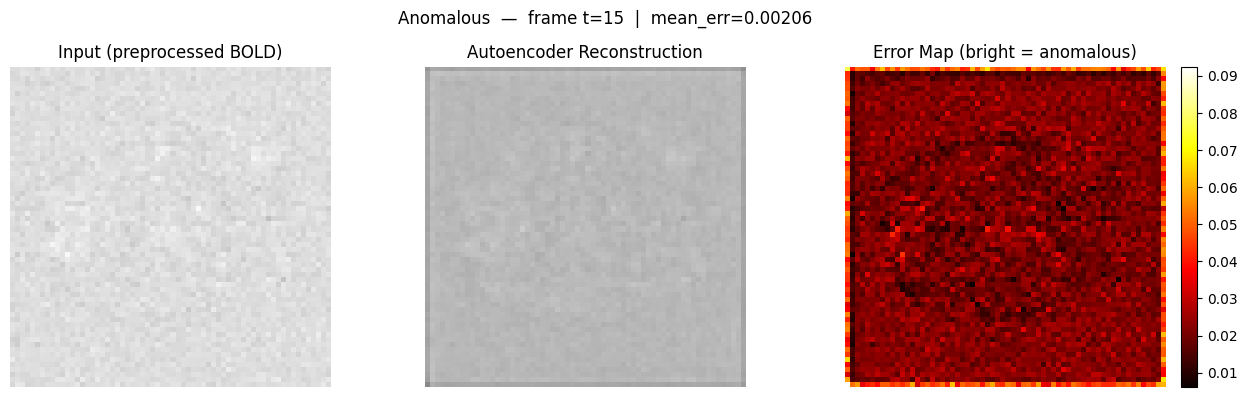

In [26]:
@torch.no_grad()
def plot_xai_heatmap(model, clips_array, idx, label, device, output_dir=None):
    """Input / Reconstruction / Error heatmap for the most anomalous frame."""
    clip = torch.from_numpy(clips_array[idx][None]).to(device)   # (1,1,T,H,W)
    recon = model(clip)

    err_map = F.mse_loss(recon, clip, reduction="none").squeeze(0).cpu().numpy()  # (1,T,H,W)
    inp_np  = clip.squeeze(0).cpu().numpy()     # (1,T,H,W)
    rec_np  = recon.squeeze(0).cpu().numpy()    # (1,T,H,W)

    # Auto-select the frame with the highest mean error
    mean_err_per_frame = err_map[0].mean(axis=(1, 2))   # (T,)
    best_t = int(mean_err_per_frame.argmax())

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    fig.suptitle(f"{label}  —  frame t={best_t}  |  mean_err={err_map.mean():.5f}",
                 fontsize=12)

    axes[0].imshow(inp_np[0, best_t], cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Input (preprocessed BOLD)"); axes[0].axis("off")

    axes[1].imshow(rec_np[0, best_t], cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Autoencoder Reconstruction"); axes[1].axis("off")

    im = axes[2].imshow(err_map[0, best_t], cmap="hot")
    axes[2].set_title("Error Map (bright = anomalous)"); axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    if output_dir:
        plt.savefig(output_dir / f"xai_heatmap_{label.lower().replace(' ','_')}.png",
                    dpi=140, bbox_inches="tight")
    plt.show()


print("── Healthy subject ──────────────────────────────────────────────────")
plot_xai_heatmap(best_model, X_test, idx=0, label="Healthy", device=DEVICE, output_dir=OUTPUT_DIR)

print("── Anomalous subject (synthetic corruption) ─────────────────────────")
anom_clips = np.stack([inject_anomaly(X_test[i], np.random.default_rng(SEED + i))
                       for i in range(len(X_test))], axis=0)
plot_xai_heatmap(best_model, anom_clips, idx=0, label="Anomalous", device=DEVICE, output_dir=OUTPUT_DIR)


## Cell 16 — XAI: Gradient-Based Saliency

**Method**: Compute the gradient of the reconstruction error with respect to the input
(∂error/∂input). Large gradients indicate voxels where a small change in input would
most increase the anomaly score — these are the voxels the model is most sensitive to.

**Advantage over heatmaps**: Heatmaps show WHERE the reconstruction failed (post-hoc).
Gradient saliency shows WHICH INPUT REGIONS drove the decision — a causal explanation.

**SmoothGrad variant**: Average gradients over N noisy copies of the input to reduce noise.

This answers: **Which brain regions caused the model to flag this subject as anomalous?**


Computing gradient saliency (SmoothGrad)...


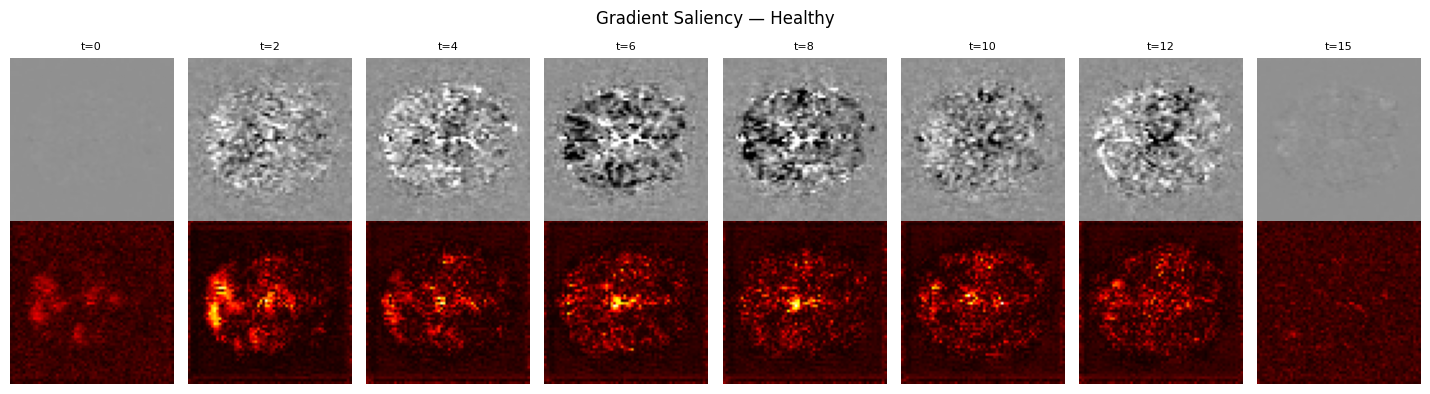

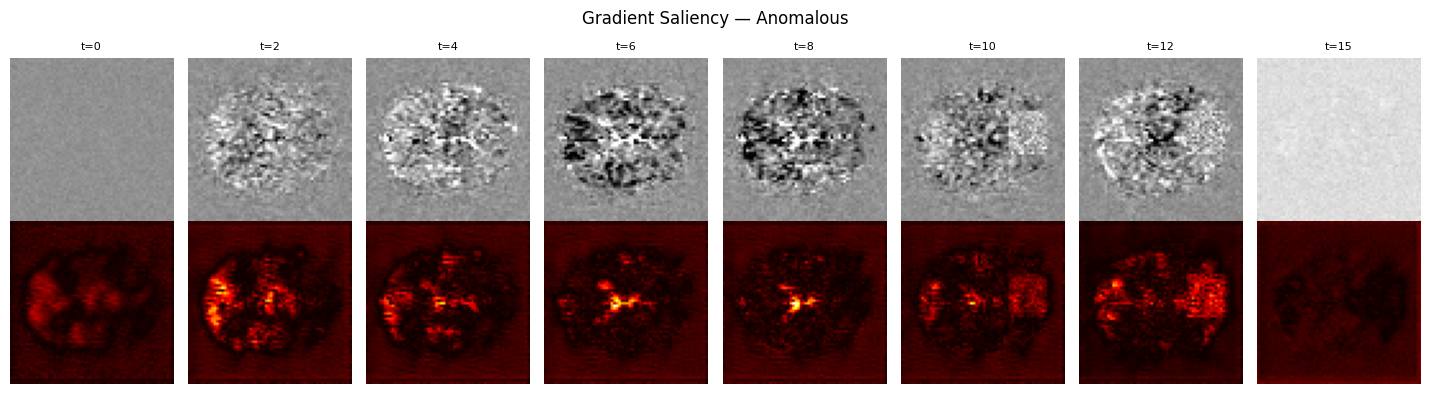

In [28]:
# =============================================================
# Cell 16 — Gradient Saliency (FIXED)
# =============================================================

def compute_gradient_saliency(clip_1thw, model, device, method="smoothgrad", n_samples=5, noise_std=0.05):
    """
    Gradient saliency: |d(MSE)/d(input)|, averaged over n_samples noisy inputs (SmoothGrad).
    Returns saliency map (1, T, H, W).
    """
    raw = unwrap(model)
    raw.eval()

    x = torch.from_numpy(clip_1thw[None]).float().to(device)  # (1,1,T,H,W)
    saliency_acc = torch.zeros_like(x)

    for _ in range(n_samples):
        noise = torch.randn_like(x) * noise_std
        xi = (x + noise).requires_grad_(True)

        raw.zero_grad()
        out = raw(xi)
        loss = F.mse_loss(out, xi.detach())
        loss.backward()

        saliency_acc += xi.grad.abs().detach()

    saliency = (saliency_acc / n_samples).squeeze(0).cpu().numpy()  # (1,T,H,W)
    # Normalize to [0,1]
    s_min, s_max = saliency.min(), saliency.max()
    if s_max > s_min:
        saliency = (saliency - s_min) / (s_max - s_min)
    return saliency


def plot_saliency(clip_1thw, saliency, label, device, output_dir=None):
    T = clip_1thw.shape[1]
    n_show = min(8, T)
    frame_ids = np.linspace(0, T - 1, n_show).astype(int)

    fig, axes = plt.subplots(2, n_show, figsize=(n_show * 1.8, 4))
    for col, t in enumerate(frame_ids):
        axes[0, col].imshow(clip_1thw[0, t], cmap="gray", vmin=0, vmax=1)
        axes[0, col].axis("off")
        axes[0, col].set_title(f"t={t}", fontsize=8)

        axes[1, col].imshow(saliency[0, t], cmap="hot", vmin=0, vmax=1)
        axes[1, col].axis("off")

    axes[0, 0].set_ylabel("Input", fontsize=9, rotation=0, ha="right", va="center")
    axes[1, 0].set_ylabel("Saliency", fontsize=9, rotation=0, ha="right", va="center")
    fig.suptitle(f"Gradient Saliency — {label}", fontsize=12)
    plt.tight_layout()
    if output_dir:
        plt.savefig(output_dir / f"xai_saliency_{label.lower().replace(' ','_')}.png",
                    dpi=130, bbox_inches="tight")
    plt.show()


print("Computing gradient saliency (SmoothGrad)...")
sal_healthy = compute_gradient_saliency(X_test[0], best_model, DEVICE)
sal_anomaly = compute_gradient_saliency(anom_clips[0], best_model, DEVICE)

# FIXED: Added device=DEVICE to both calls
plot_saliency(X_test[0], sal_healthy, label="Healthy", device=DEVICE, output_dir=OUTPUT_DIR)
plot_saliency(anom_clips[0], sal_anomaly, label="Anomalous", device=DEVICE, output_dir=OUTPUT_DIR)

## Cell 17 — XAI: Occlusion Sensitivity

**Method**: Systematically occlude (zero-out) patches of the input and measure how much
the anomaly score changes. Large score increase when a patch is removed → that patch
was important for the anomaly decision.

**Advantage**: Model-agnostic — works on any black-box model (no gradients required).

**Disadvantage**: Computationally expensive (one forward pass per patch).

**Patch size = 8 px, stride = 8 px** → 8×8 = 64 patches per frame × 16 frames.

This answers: **Which specific spatiotemporal patches CAUSED the high anomaly score?**


Computing occlusion maps (this takes ~1-2 min per subject)...


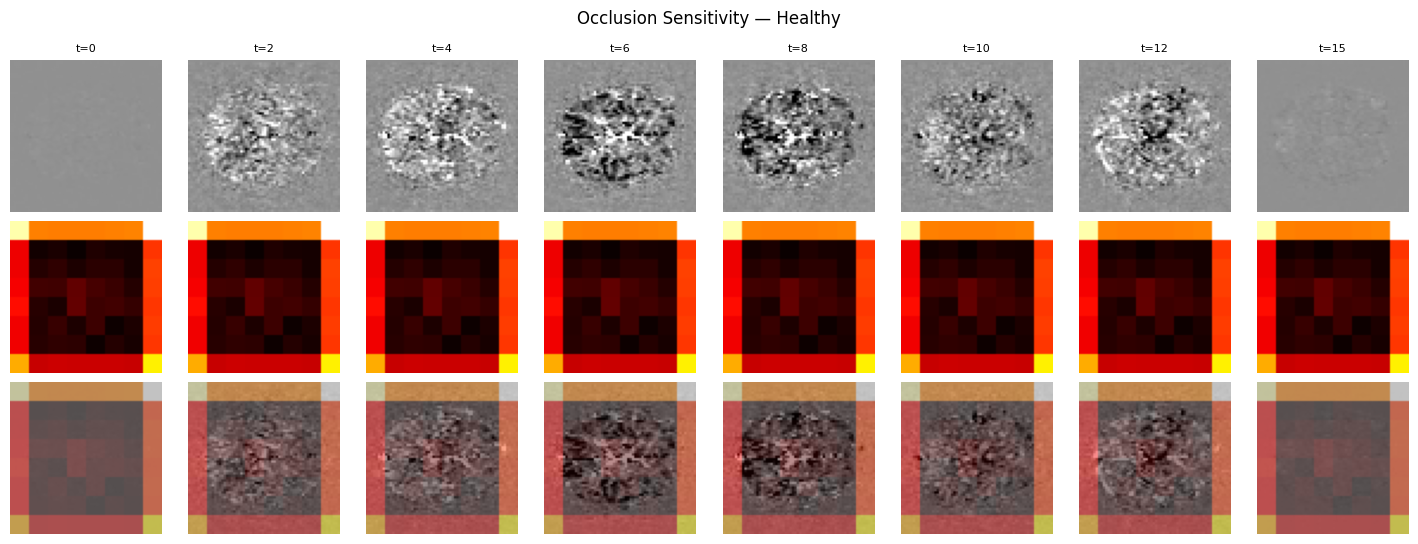

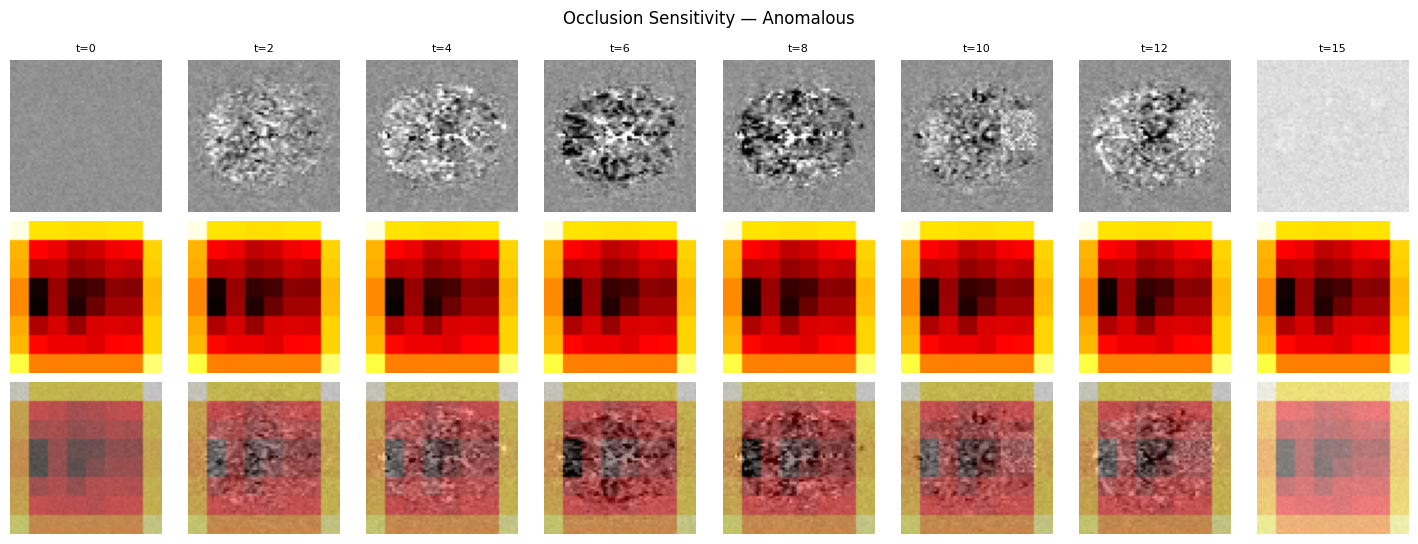

In [29]:
@torch.no_grad()
def occlusion_sensitivity(clip_1thw, model, device,
                          patch_h=8, patch_w=8, stride=8):
    """
    Occlusion sensitivity map for a single clip.
    Returns sensitivity map (1, T, H, W) — higher = more important.
    """
    raw = unwrap(model)
    raw.eval()

    clip_t = torch.from_numpy(clip_1thw[None]).float().to(device)  # (1,1,T,H,W)
    with torch.no_grad():
        baseline_err = F.mse_loss(raw(clip_t), clip_t).item()

    _, _, T, H, W = clip_t.shape
    occ_map = np.zeros((1, T, H, W), dtype=np.float32)

    # Spatial patches (same patch at every time point simultaneously)
    for y in range(0, H - patch_h + 1, stride):
        for x in range(0, W - patch_w + 1, stride):
            masked = clip_t.clone()
            masked[:, :, :, y:y+patch_h, x:x+patch_w] = 0.0
            err = F.mse_loss(raw(masked), masked).item()
            importance = err - baseline_err  # positive = region was helping reconstruction
            occ_map[0, :, y:y+patch_h, x:x+patch_w] += importance

    # Normalize
    v_min, v_max = occ_map.min(), occ_map.max()
    if v_max > v_min:
        occ_map = (occ_map - v_min) / (v_max - v_min)
    return occ_map


def plot_occlusion(clip_1thw, occ_map, label, output_dir=None):
    T = clip_1thw.shape[1]
    n_show = min(8, T)
    frame_ids = np.linspace(0, T - 1, n_show).astype(int)

    fig, axes = plt.subplots(3, n_show, figsize=(n_show * 1.8, 5.5))
    for col, t in enumerate(frame_ids):
        axes[0, col].imshow(clip_1thw[0, t], cmap="gray", vmin=0, vmax=1)
        axes[0, col].axis("off")
        axes[0, col].set_title(f"t={t}", fontsize=8)

        axes[1, col].imshow(occ_map[0, t], cmap="hot", vmin=0, vmax=1)
        axes[1, col].axis("off")

        # Overlay: heatmap on top of input
        overlay = np.stack([clip_1thw[0, t]] * 3, axis=-1)
        hot = plt.get_cmap("hot")(occ_map[0, t])[:, :, :3]
        blended = 0.55 * overlay + 0.45 * hot
        axes[2, col].imshow(np.clip(blended, 0, 1))
        axes[2, col].axis("off")

    for row, lbl in enumerate(["Input", "Occlusion", "Overlay"]):
        axes[row, 0].set_ylabel(lbl, fontsize=9, rotation=0, ha="right", va="center")

    fig.suptitle(f"Occlusion Sensitivity — {label}", fontsize=12)
    plt.tight_layout()
    if output_dir:
        plt.savefig(output_dir / f"xai_occlusion_{label.lower().replace(' ','_')}.png",
                    dpi=130, bbox_inches="tight")
    plt.show()


print("Computing occlusion maps (this takes ~1-2 min per subject)...")
occ_healthy = occlusion_sensitivity(X_test[0],     best_model, DEVICE)
occ_anomaly = occlusion_sensitivity(anom_clips[0], best_model, DEVICE)

plot_occlusion(X_test[0],     occ_healthy, label="Healthy",   output_dir=OUTPUT_DIR)
plot_occlusion(anom_clips[0], occ_anomaly, label="Anomalous", output_dir=OUTPUT_DIR)


## Cell 18 — UMAP: Latent Space Visualization

The autoencoder's bottleneck (latent representation) captures the essential structure
of each brain's functional pattern. UMAP projects these high-dimensional vectors to 2D.

**What good separation means**: If healthy and anomalous subjects cluster into distinct
regions of the latent space, the model has learned a meaningful representation of
"normal" brain dynamics — not just memorizing individual subjects.

**What to report**: Well-separated clusters support the claim that reconstruction error
is a valid anomaly score, not just noise.


2026-05-06 00:58:19.452444: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778029099.637627      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778029099.688525      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778029100.093355      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778029100.093385      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778029100.093387      57 computation_placer.cc:177] computation placer alr

Extracting bottleneck features...
Running UMAP on 32 subjects × 16 features...


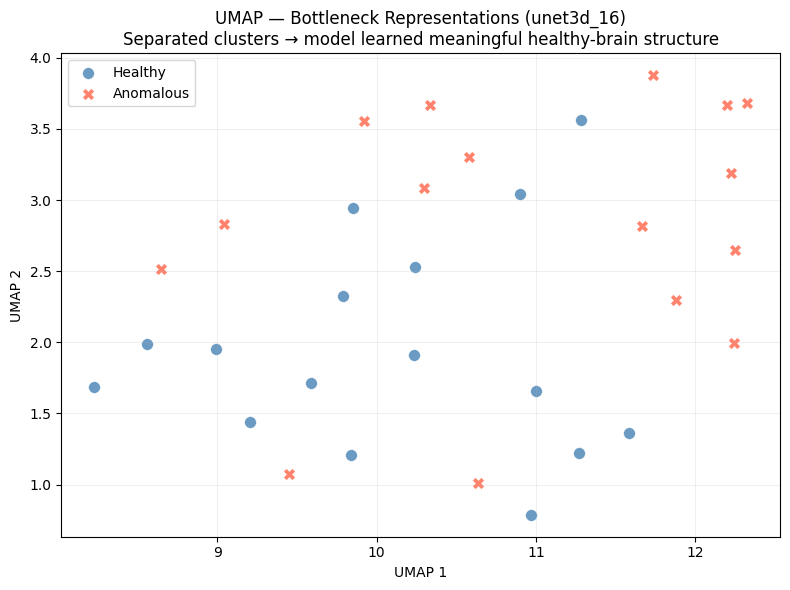

In [30]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "umap-learn"], check=True)
from umap import UMAP


@torch.no_grad()
def extract_bottleneck(model, clips_array, device, batch_size=8):
    """Extract global-average-pooled bottleneck features → (N, C) matrix."""
    raw = unwrap(model)
    raw.eval()
    vecs = []
    for start in range(0, len(clips_array), batch_size):
        batch = torch.from_numpy(clips_array[start:start+batch_size]).float().to(device)
        if hasattr(raw, "encode"):
            bot = raw.encode(batch)
        else:
            # For simpler models: use encoder output
            x = batch
            for layer in list(raw.children())[:2]:   # stem + enc1 for res3d
                x = layer(x)
            bot = x
        vecs.append(bot.mean(dim=(2, 3, 4)).cpu().numpy())  # (B, C)
    return np.concatenate(vecs, axis=0)


print("Extracting bottleneck features...")
feat_test = extract_bottleneck(best_model, X_test,     DEVICE)
feat_anom = extract_bottleneck(best_model, anom_clips, DEVICE)

all_feat = np.concatenate([feat_test, feat_anom], axis=0)
all_lbl  = ["Healthy"] * len(feat_test) + ["Anomalous"] * len(feat_anom)

print(f"Running UMAP on {len(all_feat)} subjects × {all_feat.shape[1]} features...")
reducer   = UMAP(n_components=2, random_state=SEED,
                 n_neighbors=min(15, len(all_feat) - 1))
embedding = reducer.fit_transform(all_feat)

fig, ax = plt.subplots(figsize=(8, 6))
for lbl, color, marker in [("Healthy", "steelblue", "o"), ("Anomalous", "tomato", "X")]:
    mask = np.array(all_lbl) == lbl
    ax.scatter(embedding[mask, 0], embedding[mask, 1],
               c=color, marker=marker, s=70, alpha=0.8, label=lbl, edgecolors="w", linewidths=0.3)
ax.set_title(f"UMAP — Bottleneck Representations ({best_cfg['name']})\n"
             "Separated clusters → model learned meaningful healthy-brain structure")
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "umap_bottleneck.png", dpi=140, bbox_inches="tight")
plt.show()


## Cell 19 — Demographics: Anomaly Scores by Age & Sex

A normative model should show **consistent false-positive rates across demographics**.
If anomaly scores systematically vary by age or sex among healthy subjects, it suggests
the model learned demographic confounds instead of pure brain abnormalities.

This analysis is only meaningful if metadata was produced by the preprocessing notebook.
If no metadata is available, this cell is skipped gracefully.


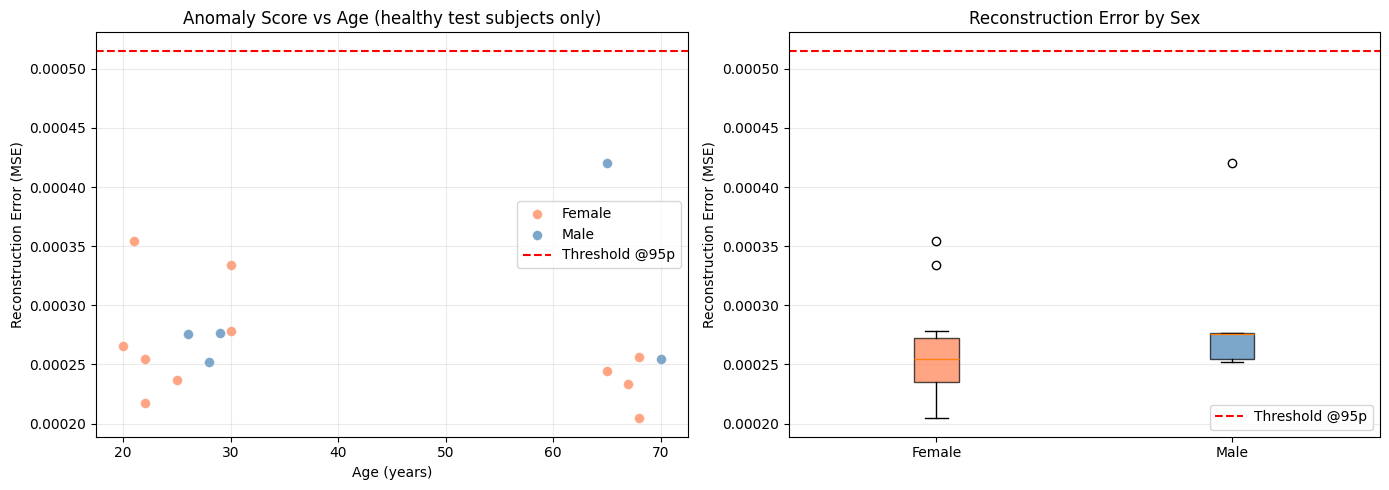


False-positive rate by sex (healthy test subjects flagged as anomalous):
  Male    : 0.000  (n=5)
  Female  : 0.000  (n=11)


In [32]:
# =============================================================
# Cell 19 — Demographics: Anomaly Scores by Age & Sex (FIXED)
# =============================================================

if df_test["age"].notna().any() and len(df_test) == len(test_err):
    df_eval = df_test.copy()
    df_eval["recon_error"] = test_err
    df_eval["anomaly_flag"] = (test_err > thresh).astype(int)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Error vs age scatter
    for sex, color in [("Female", "coral"), ("Male", "steelblue"), ("Unknown", "gray")]:
        sub = df_eval[df_eval["sex"] == sex]
        if len(sub) == 0:
            continue
        axes[0].scatter(sub["age"], sub["recon_error"],
                        color=color, alpha=0.7, s=50, label=sex, edgecolors="w", linewidths=0.3)
    axes[0].axhline(thresh, color="red", ls="--", lw=1.5, label=f"Threshold @95p")
    axes[0].set_xlabel("Age (years)")
    axes[0].set_ylabel("Reconstruction Error (MSE)")
    axes[0].set_title("Anomaly Score vs Age (healthy test subjects only)")  # ← FIXED: removed line break
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    # Error by sex boxplot
    sex_groups = [df_eval[df_eval["sex"] == s]["recon_error"].values
                  for s in ["Female", "Male"] if (df_eval["sex"] == s).any()]
    sex_labels = [s for s in ["Female", "Male"] if (df_eval["sex"] == s).any()]
    if sex_groups:
        bp = axes[1].boxplot(sex_groups, labels=sex_labels, patch_artist=True, notch=False)
        colors = ["coral", "steelblue"]
        for patch, c in zip(bp["boxes"], colors[:len(bp["boxes"])]):
            patch.set_facecolor(c)
            patch.set_alpha(0.7)
        axes[1].axhline(thresh, color="red", ls="--", lw=1.5, label="Threshold @95p")
        axes[1].set_ylabel("Reconstruction Error (MSE)")
        axes[1].set_title("Reconstruction Error by Sex")
        axes[1].legend()
        axes[1].grid(alpha=0.25, axis="y")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "demographics_analysis.png", dpi=130, bbox_inches="tight")
    plt.show()

    print("\nFalse-positive rate by sex (healthy test subjects flagged as anomalous):")
    for sex in df_eval["sex"].unique():
        sub = df_eval[df_eval["sex"] == sex]
        fpr_s = (sub["anomaly_flag"] == 1).mean()
        print(f"  {sex:8s}: {fpr_s:.3f}  (n={len(sub)})")
else:
    print("Metadata not available or length mismatch — skipping demographics analysis.")

## Cell 20 — Save Checkpoint & Inference Script

The checkpoint saved here contains everything needed to run inference on a new subject
without re-training: model config, weights, threshold, and evaluation metrics.

The companion `inference.py` script can be downloaded alongside the checkpoint and used
independently — it has no dependency on the training notebook.


In [33]:
# ── Save best model checkpoint ────────────────────────────────────────────────
ckpt_path = OUTPUT_DIR / f"best_model_{best_cfg['name']}.pt"
torch.save({
    "config":     best_cfg,
    "state_dict": best_state,
    "n_frames":   N_FRAMES,
    "hw":         HW,
    "threshold":  float(thresh),
    "auc":        float(auc),
    "benchmark":  benchmark_df.to_dict("records"),
}, ckpt_path)
print(f"Saved checkpoint → {ckpt_path}  ({ckpt_path.stat().st_size/1e6:.1f} MB)")

# ── Self-contained inference script ───────────────────────────────────────────
inference_code = """
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from pathlib import Path


def _gn(c, mg=8):
    g = min(mg, c)
    while c % g != 0: g -= 1
    return nn.GroupNorm(g, c)

class _RB(nn.Module):
    def __init__(self, c, d=0.0):
        super().__init__()
        self.n1,self.cv1,self.n2,self.cv2 = _gn(c),nn.Conv3d(c,c,3,padding=1),_gn(c),nn.Conv3d(c,c,3,padding=1)
        self.drop = nn.Dropout3d(d) if d > 0 else nn.Identity()
    def forward(self,x):
        r=x; x=self.cv1(F.silu(self.n1(x))); x=self.drop(x); x=self.cv2(F.silu(self.n2(x))); return x+r

class _AE(nn.Module):
    def __init__(self,bc=24,dp=0.0):
        super().__init__()
        c1,c2,c3,c4=[bc*(2**i) for i in range(4)]
        self.stem=nn.Conv3d(1,c1,3,padding=1)
        self.e1=_RB(c1,dp); self.d1=nn.Conv3d(c1,c2,3,stride=2,padding=1)
        self.e2=_RB(c2,dp); self.d2=nn.Conv3d(c2,c3,3,stride=2,padding=1)
        self.e3=_RB(c3,dp); self.d3=nn.Conv3d(c3,c4,3,stride=2,padding=1)
        self.bot=nn.Sequential(_RB(c4,dp),_RB(c4,dp))
        self.u3=nn.ConvTranspose3d(c4,c3,2,stride=2); self.dc3=_RB(c3,dp)
        self.u2=nn.ConvTranspose3d(c3,c2,2,stride=2); self.dc2=_RB(c2,dp)
        self.u1=nn.ConvTranspose3d(c2,c1,2,stride=2); self.dc1=_RB(c1,dp)
        self.out=nn.Conv3d(c1,1,3,padding=1)
    def forward(self,x):
        x=self.stem(x); x1=self.e1(x); x2=self.e2(self.d1(x1)); x3=self.e3(self.d2(x2))
        xb=self.bot(self.d3(x3)); x=self.dc3(self.u3(xb)+x3)
        x=self.dc2(self.u2(x)+x2); x=self.dc1(self.u1(x)+x1)
        return torch.sigmoid(self.out(x))

class AnomalyDetector:
    def __init__(self, ckpt_path, device=None):
        ckpt = torch.load(ckpt_path, map_location='cpu')
        cfg  = ckpt['config']
        self.thresh    = ckpt.get('threshold')
        self.n_frames  = ckpt['n_frames']
        self.hw        = ckpt['hw']
        self.device    = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = _AE(bc=cfg.get('base_channels',24), dp=cfg.get('dropout',0.0)).to(self.device)
        self.model.load_state_dict(ckpt['state_dict']); self.model.eval()
        print(f'Loaded on {self.device}  threshold={self.thresh:.6f}')

    def score(self, clip_npy):
        '''clip_npy: numpy (1, T, H, W) float32 in [0,1]'''
        x = torch.from_numpy(clip_npy[None]).float().to(self.device)
        with torch.no_grad():
            recon = self.model(x)
        err_map = F.mse_loss(recon, x, reduction='none').squeeze(0).cpu().numpy()
        return float(err_map.mean()), err_map

    def is_anomaly(self, score): return score > self.thresh

# Usage:
# det = AnomalyDetector('best_model_res3d_24.pt')
# score, heatmap = det.score(clip_1thw)
# print('Anomaly:', det.is_anomaly(score))
"""

script_path = OUTPUT_DIR / "inference.py"
script_path.write_text(inference_code.strip())
print(f"Saved inference script → {script_path}")
print("\nDownload from: Kaggle > Output panel > best_model_*.pt + inference.py")


Saved checkpoint → /kaggle/working/best_model_unet3d_16.pt  (1.4 MB)
Saved inference script → /kaggle/working/inference.py

Download from: Kaggle > Output panel > best_model_*.pt + inference.py


## Cell 21 — Final Results Summary


In [34]:
print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"Best model        : {best_cfg['name']}  (arch={best_cfg['arch']})")
print(f"AUC               : {auc:.4f}")
print(f"Average Precision : {ap:.4f}")
print(f"TPR (anomaly)@95p : {tpr:.4f}")
print(f"FPR (healthy)@95p : {fpr:.4f}")
print(f"Cohen's d         : {cohen_d:.3f}  ({label_d} separation)")
print(f"Threshold @95p    : {thresh:.6f}")
print()
print("Model Benchmark:")
print(benchmark_df[["name", "auc", "tpr_anomaly", "fpr_healthy"]].to_string(index=False))
print()
print("Files saved to /kaggle/working:")
for f in sorted(OUTPUT_DIR.glob("*.pt")) + sorted(OUTPUT_DIR.glob("*.py")) + sorted(OUTPUT_DIR.glob("*.png")):
    print(f"  {f.name:45s}  {f.stat().st_size/1e3:7.1f} KB")


FINAL RESULTS SUMMARY
Best model        : unet3d_16  (arch=unet3d)
AUC               : 1.0000
Average Precision : 1.0000
TPR (anomaly)@95p : 1.0000
FPR (healthy)@95p : 0.0000
Cohen's d         : 2.657  (excellent separation)
Threshold @95p    : 0.000515

Model Benchmark:
     name      auc  tpr_anomaly  fpr_healthy
unet3d_16 1.000000         1.00       0.0000
 res3d_24 1.000000         1.00       0.0000
simple_3d 0.929688         0.50       0.1250
simple_2d 0.578125         0.25       0.1875

Files saved to /kaggle/working:
  best_model_unet3d_16.pt                         1374.8 KB
  inference.py                                       2.8 KB
  demographics_analysis.png                         65.0 KB
  healthy_vs_anomaly.png                           602.2 KB
  per_subject_scatter.png                           59.1 KB
  roc_pr_curves.png                                 61.3 KB
  sample_clips.png                                 923.0 KB
  training_results.png                            